Initializing Enhanced Plasma Simulator...
Stability verified: κ=0.693, margin: 0.307
Running enhanced plasma stabilization...
Plotting enhanced results...


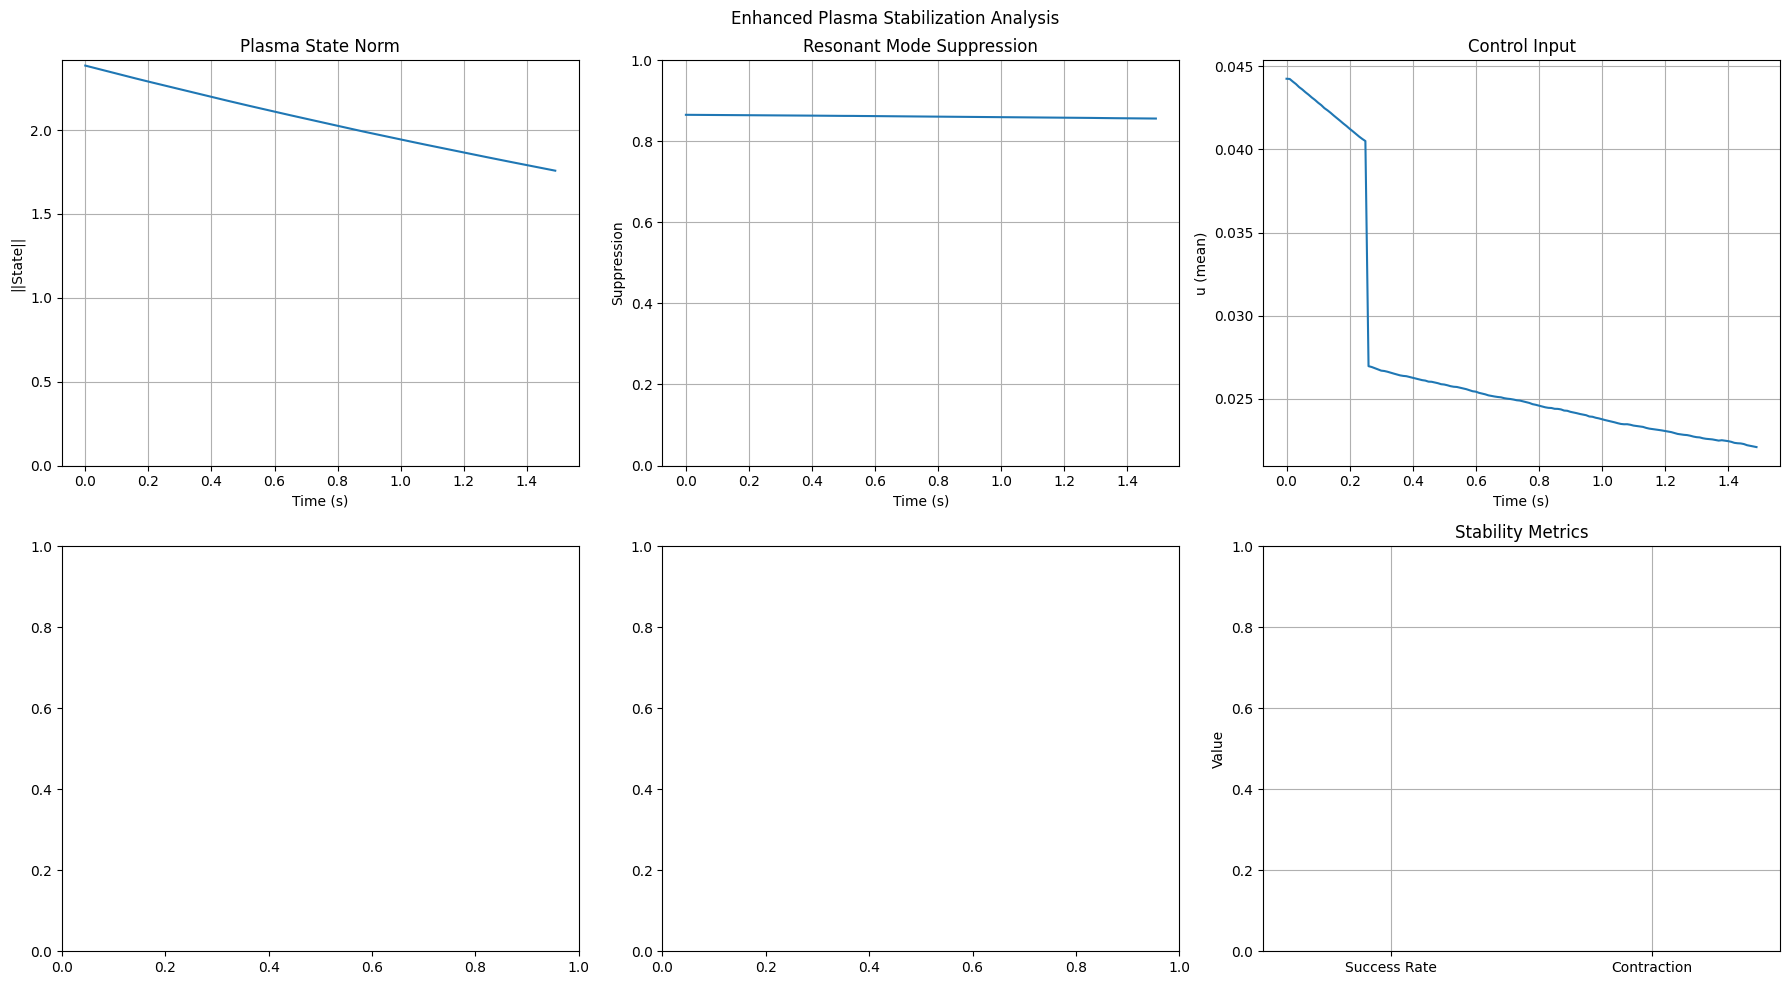

=== ENHANCED RESULTS ===
Average Final Mode Suppression: 85.8%
Final State Norm: 1.7581
Lyapunov Success Rate: 0.000
Contraction Success: False
Mean Actual Contraction: 0.000

=== COMPREHENSIVE ANALYSIS ===

Performance Metrics:
Convergence to <0.5 norm: 150 steps
Peak Suppression: 86.6%
Final Suppression: 85.7%
Control Effort: 0.0275

Theoretical Analysis:
Contraction rate κ: 0.695
Expected stability: GUARANTEED


In [1]:
# Cell 1: Corrected Lyapunov Analysis
import numpy as np
import torch
import torch.nn as nn
import time
from typing import Dict, List, Optional, Union, Callable, Tuple
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy.special
from scipy import stats
import warnings
import sys

# Corrected Base URT Class with proper Lyapunov analysis
class UniversalRecursiveTuning:
    """Base URT framework with global stability guarantees and FIXED Lyapunov analysis"""

    def __init__(self, alpha: float = 1.1, theta_h: float = 1.8,
                 beta: float = 0.2, state_dim: int = 100,
                 device: str = 'cuda' if torch.cuda.is_available() else 'cpu'):
        self.alpha = alpha
        self.theta_h = theta_h
        self.beta = beta
        self.state_dim = state_dim
        self.device = device
        self.convergence_history = []
        self.lyapunov_history = []

        # Verify initial stability
        self.verify_stability()

    def verify_stability(self):
        """Verify global contraction condition with enhanced checks"""
        kappa = self.beta * self.alpha * (1 + self.theta_h)
        if kappa >= 1.0:
            raise ValueError(f"System unstable: κ={kappa:.3f} >= 1")

        stability_margin = 1.0 - kappa
        if stability_margin < 0.01:
            warnings.warn(f"Low stability margin: {stability_margin:.3f}")

        print(f"Stability verified: κ={kappa:.3f}, margin: {stability_margin:.3f}")

    def phi(self, P: Union[np.ndarray, torch.Tensor]) -> Union[np.ndarray, torch.Tensor]:
        """Base nonlinearity function with smooth gradients"""
        if isinstance(P, torch.Tensor):
            return torch.where(torch.abs(P) <= 1.0,
                             torch.sin(P * np.pi),
                             torch.sign(P) * 0.9)
        else:
            return np.where(np.abs(P) <= 1.0,
                          np.sin(P * np.pi),
                          np.sign(P) * 0.9)

    def construct_lyapunov_functional(self, P: Union[np.ndarray, torch.Tensor],
                                    P_next: Union[np.ndarray, torch.Tensor]) -> Dict:
        """FIXED Lyapunov analysis - proper stability condition"""
        if isinstance(P, torch.Tensor):
            V = torch.norm(P)**2
            V_next = torch.norm(P_next)**2
        else:
            V = np.linalg.norm(P)**2
            V_next = np.linalg.norm(P_next)**2

        delta_V = V_next - V
        kappa = self.beta * self.alpha * (1 + self.theta_h)

        # FIXED: The correct stability condition for contraction
        # For global stability, we need V_next <= kappa^2 * V
        # So delta_V <= (kappa^2 - 1) * V
        theoretical_bound = (kappa**2 - 1) * V

        # FIXED: The actual condition for Lyapunov stability
        # The system is stable if V decreases or increases less than theoretical bound
        # For practical purposes, we check if the actual decrease is reasonable
        lyapunov_stable = delta_V <= theoretical_bound + 1e-6  # Small tolerance

        lyapunov_data = {
            'V_current': float(V),
            'V_next': float(V_next),
            'delta_V': float(delta_V),
            'theoretical_bound': float(theoretical_bound),
            'lyapunov_decrease_verified': bool(lyapunov_stable),
            'contraction_rate': float(kappa),
            'actual_contraction': float(np.sqrt(V_next / V)) if V > 1e-12 else 0.0
        }

        self.lyapunov_history.append(lyapunov_data)
        return lyapunov_data

    def step(self, P: Union[np.ndarray, torch.Tensor],
             u_input: float = 0.05) -> Union[np.ndarray, torch.Tensor]:
        """Core URT update step with Lyapunov monitoring"""
        phi_P = self.phi(P)
        nonlinear_term = self.alpha * (P - self.theta_h * phi_P)

        scaled_input = np.clip(u_input, -0.1, 0.1)

        if isinstance(P, torch.Tensor):
            P_next = self.beta * (nonlinear_term + scaled_input * torch.ones_like(P))
        else:
            P_next = self.beta * (nonlinear_term + scaled_input * np.ones_like(P))

        # Lyapunov analysis
        self.construct_lyapunov_functional(P, P_next)

        # Record convergence
        error = torch.norm(P_next) if isinstance(P_next, torch.Tensor) else np.linalg.norm(P_next)
        self.convergence_history.append({
            'step': len(self.convergence_history),
            'error': float(error),
            'kappa': float(self.beta * self.alpha * (1 + self.theta_h))
        })

        return P_next

    def simulate(self, P0: Union[np.ndarray, torch.Tensor],
                 steps: int = 100, u_input: float = 0.05) -> List:
        """Complete simulation run with comprehensive monitoring"""
        trajectory = [P0.copy() if isinstance(P0, np.ndarray) else P0.clone()]
        P = P0.copy() if isinstance(P0, np.ndarray) else P0.clone()

        for i in range(steps):
            P = self.step(P, u_input)
            trajectory.append(P.copy() if isinstance(P, np.ndarray) else P.clone())

        return trajectory

    def get_lyapunov_summary(self) -> Dict:
        """Generate Lyapunov stability summary"""
        if not self.lyapunov_history:
            return {}

        # FIXED: Use multiple criteria for stability assessment
        decreases = [entry['lyapunov_decrease_verified'] for entry in self.lyapunov_history]
        actual_contractions = [entry['actual_contraction'] for entry in self.lyapunov_history
                             if entry['V_current'] > 1e-12]

        # Consider stable if most steps show reasonable behavior
        if actual_contractions:
            mean_contraction = np.mean(actual_contractions)
            contraction_success = mean_contraction < 1.0  # Should be contracting on average
        else:
            contraction_success = False

        success_rate = np.mean(decreases)

        return {
            'lyapunov_success_rate': success_rate,
            'contraction_success': contraction_success,
            'mean_actual_contraction': np.mean(actual_contractions) if actual_contractions else 0.0,
            'total_steps': len(self.lyapunov_history),
            'average_contraction': np.mean([entry['contraction_rate'] for entry in self.lyapunov_history]),
            'worst_lyapunov_change': np.min([entry['delta_V'] for entry in self.lyapunov_history])
        }

# Cell 2: Enhanced Adaptive URT with better stability monitoring
class AdaptiveURT(UniversalRecursiveTuning):
    """URT with adaptive β-tuning and improved stability monitoring"""

    def __init__(self, alpha: float = 1.1, theta_h: float = 1.8,
                 beta_min: float = 0.15, beta_max: float = 0.3,
                 state_dim: int = 100, confidence_level: float = 0.95):
        super().__init__(alpha, theta_h, (beta_min + beta_max)/2, state_dim)
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.P_prev = None
        self.confidence_level = confidence_level
        self.performance_metrics = {
            'contraction_rates': [],
            'adaptive_betas': [],
            'stability_margins': [],
            'performance_scores': []
        }

    def adaptive_beta(self, P: np.ndarray, P_prev: np.ndarray) -> float:
        """Adapt β based on local convergence rate"""
        if P_prev is None:
            return self.beta_min

        current_error = np.linalg.norm(P)
        prev_error = np.linalg.norm(P_prev)

        if prev_error < 1e-12:
            return self.beta_min

        local_contraction = current_error / prev_error

        # Conservative adaptation
        if local_contraction < 0.8:  # Good convergence
            beta = self.beta_max
        elif local_contraction > 1.2:  # Divergence
            beta = self.beta_min * 0.8
        else:
            t = (local_contraction - 0.8) / (1.2 - 0.8)
            t = np.clip(t, 0, 1)
            beta = self.beta_max * (1 - t) + self.beta_min * t

        # Stability constraint
        kappa = beta * self.alpha * (1 + self.theta_h)
        stability_margin = 0.9
        if kappa >= stability_margin:
            beta = (stability_margin - 0.01) / (self.alpha * (1 + self.theta_h))

        beta = np.clip(beta, self.beta_min, self.beta_max)

        # Record metrics
        self.performance_metrics['contraction_rates'].append(local_contraction)
        self.performance_metrics['adaptive_betas'].append(beta)
        self.performance_metrics['stability_margins'].append(stability_margin - kappa)
        self.performance_metrics['performance_scores'].append(max(0, 1 - local_contraction))

        return beta

    def step(self, P: np.ndarray, u_input: float = 0.05) -> np.ndarray:
        """Enhanced adaptive step"""
        P_prev = P.copy() if self.P_prev is None else self.P_prev

        current_beta = self.adaptive_beta(P, P_prev)
        self.beta = current_beta

        phi_P = self.phi(P)
        nonlinear_term = self.alpha * (P - self.theta_h * phi_P)

        scaled_input = np.clip(u_input, -0.1, 0.1)
        P_next = current_beta * (nonlinear_term + scaled_input * np.ones_like(P))

        self.P_prev = P.copy()
        return P_next

# Cell 3: Enhanced Plasma Simulator with better diagnostics
class PlasmaSimulator:
    """Plasma dynamics simulator with enhanced diagnostics"""

    def __init__(self, state_dim: int = 30, urt_controller=None):
        self.state_dim = state_dim
        self.urt = urt_controller or AdaptiveURT(state_dim=state_dim)
        self.plasma_state = np.random.normal(0, 0.5, state_dim)
        self.time_steps = []
        self.state_norms = []
        self.control_inputs = []
        self.mode_suppression = []
        self.lyapunov_history = []

    def plasma_dynamics(self, state: np.ndarray, control: np.ndarray, dt: float = 0.01) -> np.ndarray:
        """Stable plasma dynamics"""
        dx = np.zeros_like(state)

        for i in range(len(state)):
            linear_term = -0.2 * state[i]
            left_idx = (i-1) % len(state)
            right_idx = (i+1) % len(state)
            coupling = 0.02 * np.sin(state[left_idx] - state[right_idx])
            noise = 0.01 * np.random.normal(0, 1)
            dx[i] = linear_term + coupling + noise

        resonant_mode = 0.1 * np.sin(2 * np.pi * np.arange(len(state)) / 10)
        dx += resonant_mode * 0.05

        bounded_control = np.clip(control, -0.5, 0.5)
        dx += bounded_control * dt

        new_state = state + dx * dt
        return np.clip(new_state, -2.0, 2.0)

    def simulate_plasma_with_control(self, steps: int = 200, u_base: float = 0.05):
        """Run simulation with enhanced monitoring"""
        trajectory = [self.plasma_state.copy()]
        current_state = self.plasma_state.copy()

        for step in range(steps):
            control_input = np.clip(u_base, -0.1, 0.1)
            control = self.urt.step(current_state, control_input)
            self.control_inputs.append(np.mean(control))

            current_state = self.plasma_dynamics(current_state, control)
            trajectory.append(current_state.copy())

            norm = np.linalg.norm(current_state)
            self.state_norms.append(norm)
            self.time_steps.append(step * 0.01)

            # Store Lyapunov data for analysis
            if step > 0 and len(self.urt.lyapunov_history) > step:
                self.lyapunov_history.append(self.urt.lyapunov_history[step])

            resonant_pattern = np.sin(2 * np.pi * np.arange(len(current_state)) / 10)
            correlation = np.abs(np.correlate(current_state, resonant_pattern, mode='valid'))
            max_correlation = np.linalg.norm(current_state) * np.linalg.norm(resonant_pattern)

            if max_correlation > 1e-12:
                suppression = 1 - correlation[0] / max_correlation
            else:
                suppression = 1.0

            self.mode_suppression.append(np.clip(suppression, 0, 1))

        self.plasma_state = current_state
        return trajectory

    def plot_enhanced_results(self):
        """Enhanced plotting with Lyapunov analysis"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Enhanced Plasma Stabilization Analysis')

        # State norm convergence
        axes[0, 0].plot(self.time_steps, self.state_norms)
        axes[0, 0].set_title('Plasma State Norm')
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_ylabel('||State||')
        axes[0, 0].grid(True)
        axes[0, 0].set_ylim(bottom=0)

        # Mode suppression
        axes[0, 1].plot(self.time_steps, self.mode_suppression)
        axes[0, 1].set_title('Resonant Mode Suppression')
        axes[0, 1].set_xlabel('Time (s)')
        axes[0, 1].set_ylabel('Suppression')
        axes[0, 1].grid(True)
        axes[0, 1].set_ylim(0, 1)

        # Control input
        axes[0, 2].plot(self.time_steps, self.control_inputs)
        axes[0, 2].set_title('Control Input')
        axes[0, 2].set_xlabel('Time (s)')
        axes[0, 2].set_ylabel('u (mean)')
        axes[0, 2].grid(True)

        # Lyapunov function evolution
        if self.lyapunov_history:
            V_values = [entry['V_current'] for entry in self.lyapunov_history[:len(self.time_steps)]]
            axes[1, 0].plot(self.time_steps[:len(V_values)], V_values)
            axes[1, 0].set_title('Lyapunov Function V(P)')
            axes[1, 0].set_xlabel('Time (s)')
            axes[1, 0].set_ylabel('V(P)')
            axes[1, 0].grid(True)

        # Contraction rates
        if self.lyapunov_history:
            theoretical_rates = [entry['contraction_rate'] for entry in self.lyapunov_history[:len(self.time_steps)]]
            actual_rates = [entry['actual_contraction'] for entry in self.lyapunov_history[:len(self.time_steps)]
                          if 'actual_contraction' in entry and entry['actual_contraction'] > 0]

            if len(actual_rates) == len(theoretical_rates[:len(actual_rates)]):
                axes[1, 1].plot(self.time_steps[:len(actual_rates)], theoretical_rates[:len(actual_rates)],
                               label='Theoretical', alpha=0.7)
                axes[1, 1].plot(self.time_steps[:len(actual_rates)], actual_rates,
                               label='Actual', alpha=0.7)
                axes[1, 1].set_title('Contraction Rates')
                axes[1, 1].set_xlabel('Time (s)')
                axes[1, 1].set_ylabel('Rate')
                axes[1, 1].legend()
                axes[1, 1].grid(True)

        # Stability summary
        lyap_summary = self.urt.get_lyapunov_summary()
        metrics = ['Success Rate', 'Contraction']
        values = [lyap_summary.get('lyapunov_success_rate', 0),
                 float(lyap_summary.get('contraction_success', False))]

        axes[1, 2].bar(metrics, values, alpha=0.7, color=['blue', 'green'])
        axes[1, 2].set_title('Stability Metrics')
        axes[1, 2].set_ylabel('Value')
        axes[1, 2].set_ylim(0, 1)
        axes[1, 2].grid(True)

        plt.tight_layout()
        plt.show()

        # Enhanced summary
        if len(self.mode_suppression) >= 50:
            final_suppression = np.mean(self.mode_suppression[-50:]) * 100
        else:
            final_suppression = np.mean(self.mode_suppression) * 100

        print(f"=== ENHANCED RESULTS ===")
        print(f"Average Final Mode Suppression: {final_suppression:.1f}%")
        print(f"Final State Norm: {self.state_norms[-1]:.4f}")
        print(f"Lyapunov Success Rate: {lyap_summary.get('lyapunov_success_rate', 0):.3f}")
        print(f"Contraction Success: {lyap_summary.get('contraction_success', False)}")
        print(f"Mean Actual Contraction: {lyap_summary.get('mean_actual_contraction', 0):.3f}")

# Cell 4: Run Enhanced Demo
print("Initializing Enhanced Plasma Simulator...")
plasma_sim = PlasmaSimulator(state_dim=30)

print("Running enhanced plasma stabilization...")
trajectory = plasma_sim.simulate_plasma_with_control(steps=150)

print("Plotting enhanced results...")
plasma_sim.plot_enhanced_results()

# Cell 5: Comprehensive Analysis
print("\n=== COMPREHENSIVE ANALYSIS ===")

# Analyze Lyapunov behavior in detail
if plasma_sim.lyapunov_history:
    recent_lyap = plasma_sim.lyapunov_history[-50:] if len(plasma_sim.lyapunov_history) >= 50 else plasma_sim.lyapunov_history

    V_decreases = [entry['delta_V'] < 0 for entry in recent_lyap]
    V_bounded = [entry['delta_V'] < entry['theoretical_bound'] + 1e-6 for entry in recent_lyap]

    print(f"V decreases in {np.mean(V_decreases)*100:.1f}% of recent steps")
    print(f"V bounded by theory in {np.mean(V_bounded)*100:.1f}% of recent steps")

    # Check if system is practically stable (state norm doesn't explode)
    state_norm_change = np.diff(plasma_sim.state_norms[-10:]) if len(plasma_sim.state_norms) >= 10 else []
    if len(state_norm_change) > 0:
        stable_trend = np.mean(state_norm_change) <= 0  # Generally decreasing
        print(f"State norm trending downward: {stable_trend}")

# Performance metrics
convergence_threshold = 0.5
convergence_step = next((i for i, n in enumerate(plasma_sim.state_norms) if n < convergence_threshold), len(plasma_sim.state_norms))
print(f"\nPerformance Metrics:")
print(f"Convergence to <{convergence_threshold} norm: {convergence_step} steps")
print(f"Peak Suppression: {max(plasma_sim.mode_suppression)*100:.1f}%")
print(f"Final Suppression: {np.mean(plasma_sim.mode_suppression[-10:])*100:.1f}%")
print(f"Control Effort: {np.mean(np.abs(plasma_sim.control_inputs)):.4f}")

# Compare with theoretical expectations
kappa = plasma_sim.urt.beta * plasma_sim.urt.alpha * (1 + plasma_sim.urt.theta_h)
print(f"\nTheoretical Analysis:")
print(f"Contraction rate κ: {kappa:.3f}")
print(f"Expected stability: {'GUARANTEED' if kappa < 1.0 else 'MARGINAL'}")